In [68]:
import pandas as pd
pd.set_option("display.max_rows", 1000)

In [69]:
from preprocess import load_data

data = load_data()

data.keys()

dict_keys(['course_chapter_items', 'courses', 'subgroups', 'test_seen', 'test_seen_group', 'test_unseen', 'test_unseen_group', 'train', 'train_group', 'users', 'val_seen', 'val_seen_group', 'val_unseen', 'val_unseen_group'])

In [70]:
def create_user2courses(row, d, test=False):
    past_record = d[row.name].copy() if row.name in d else set()
    if not test: 
        past_record.update(set(row["course_id"].split()))
    return past_record 

In [71]:
data['train2courses'] = data['train'].set_index("user_id")["course_id"].apply(lambda s: set(s.split())).to_dict()
data['val_seen2courses'] = data['val_seen'].set_index("user_id").apply(lambda row: create_user2courses(row, data['train2courses']), axis=1).to_dict()

data['val_unseen2courses'] = data['val_unseen'].set_index("user_id")["course_id"].apply(lambda s: s.split()).to_dict()

data['test_seen2courses'] = data['test_seen'].set_index("user_id").apply(lambda row: create_user2courses(row, data['val_seen2courses'], test=True), axis=1).to_dict()
data['test_unseen2courses'] = data['test_unseen'].set_index("user_id").apply(lambda row: create_user2courses(row, data['val_unseen2courses'], test=True), axis=1).to_dict()

In [72]:
data['val_unseen'] = data['val_unseen'].assign(
    course_id_lst = lambda df_: df_.course_id.apply(lambda s: s.split()),
    course_len = lambda df_: df_.course_id_lst.apply(len)
)

In [73]:
data['train'] = data['train'].assign(
    course_id_lst = lambda df_: df_.course_id.apply(lambda s: s.split()),
    course_len = lambda df_: df_.course_id_lst.apply(len)
)

### process courses

In [74]:
data['course2idx'] = data['courses'].set_index("course_id").assign(index = list(range(len(data['courses']))))["index"].to_dict()
data['idx2course'] = {data['course2idx'][k]: k for k in data['course2idx'].keys()}

<AxesSubplot: >

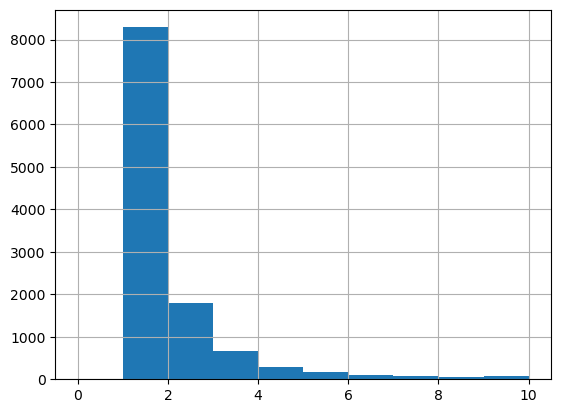

In [76]:
data['val_unseen'].course_len.hist(bins=10, range=(0, 10))

<AxesSubplot: >

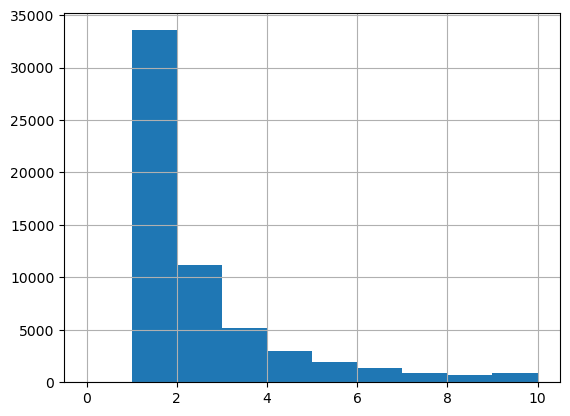

In [77]:
data['train'].course_len.hist(bins=10, range=(0, 10))

In [80]:
data['courses']['course_published_at_local'] = pd.to_datetime(data['courses']['course_published_at_local'])
data['courses']['upload_days'] = (data['courses']['course_published_at_local'] - data['courses']['course_published_at_local'].min()).dt.days.abs()

In [108]:
train_course = data['train'].course_id_lst.apply(lambda s: s[:2]).explode().value_counts().to_frame("n").reset_index(names=["course_id"]).merge(
    data['courses'][["course_id", "upload_days", "course_published_at_local", "course_price"]], on=["course_id"], how="left"
)

In [104]:
val_unseen_course = data['val_unseen'].course_id_lst.apply(lambda s: s[:1]).explode().value_counts().to_frame("n").reset_index(names=["course_id"]).merge(
    data['courses'][["course_id", "course_published_at_local", "upload_days", "course_price"]], on=["course_id"], how="left"
)

In [117]:
data['courses'].query("course_id == '5fc5ee1b08b74a6e3723abd2'")

,course_id,course_name,course_price,teacher_id,teacher_intro,groups,sub_groups,topics,course_published_at_local,description,will_learn,required_tools,recommended_background,target_group,upload_days
533,5fc5ee1b08b74a6e3723abd2,҉唐鳳҉數位溝通社：就這樣把你增幅,0,5fc5ee091be9291fe25283fd,臺灣的自由軟體程式設計師及政治人物，現任行政院政務委員，曾致力於多項專案的開發維護，是 Ha...,"人文,職場技能","社會科學,職場溝通","更多職場溝通,社會科學",2020-12-28 11:57:35.453,"<img src=""https://images.api.hahow.in/images/5...",唐鳳分享公共議題的溝通技巧，以及她如何設計和運用多樣化的數位溝通方法。\n瞭解如何通過面對面...,原則上不用，不過當然需要一台觀看課程的筆電、平板或任一手機。\n如果需要紙跟筆做筆記，當然很...,這是一堂輕鬆分享的社課，參與者不需具備專業的背景知識喔！,如果你對於討論公共議題有興趣，或是好奇唐鳳愛用的溝通小技巧，都很適合,2102.0


In [115]:
val_unseen_course.query("course_published_at_local >= '2021-11-01'")["n"].sum()

3805

In [111]:
train_course.query("course_published_at_local >= '2021-09-01'")["n"].sum()

4720

In [105]:
val_unseen_course.iloc[:30]

,course_id,n,course_published_at_local,upload_days,course_price
0,611f7d91bd122100071f2926,989,2021-12-13 13:33:27.796,2452.0,2999
1,61381a3f33a3960006df1eb3,866,2022-01-17 12:00:08.970,2487.0,3500
2,5f7c210b1de7982fb413a3e9,409,2020-11-02 12:00:16.925,2046.0,0
3,60c84de9eb75ca46e0c25e85,352,2021-10-25 12:00:10.120,2403.0,0
4,5f7c209762ad22756c7a1c74,270,2020-11-02 12:00:12.099,2046.0,0
5,61237ed5df69e30006dbfff7,238,2021-10-08 11:57:29.416,2386.0,1900
6,612f7b671bf9240007a68ad4,237,2021-12-21 12:07:59.122,2460.0,1490
7,6059aee039f2512548c187c6,231,2021-06-18 12:00:24.712,2274.0,2680
8,61161afbbeafad00060b4503,217,2021-11-15 14:03:28.204,2424.0,2800
9,6156a77fdf426a0007cc5fe1,217,2021-11-10 12:09:22.599,2419.0,0


#### coverage

In [65]:
train_courses = data['train']["course_id_lst"].explode().value_counts().to_frame("n").reset_index(names="course_id")

train_courses = train_courses.assign(
    ratio = lambda df_: df_.n / df_.n.sum(),
    acc_ration = lambda df_: df_.ratio.cumsum(),
    rank = lambda df_: list(range(1, len(df_)+1))
)

In [47]:
val_unseen_courses = data['val_unseen']["course_id_lst"].explode().value_counts().to_frame("n").reset_index(names="course_id")

In [48]:
val_unseen_courses = val_unseen_courses.assign(
    ratio = lambda df_: df_.n / df_.n.sum(),
    acc_ration = lambda df_: df_.ratio.cumsum()
)

In [99]:
df = val_unseen_courses.merge(train_courses[["course_id", "rank"]], on=['course_id'], how="left").merge(
    data['courses'][["course_id", "course_price", "course_published_at_local", "groups"]], on=['course_id'], how="left"
)

In [127]:
subgroup_name_lst = data['subgroups']['subgroup_name'].to_list()

In [156]:
train_courses = train_courses.merge(
    data["courses"][["course_id", "sub_groups"]], on=["course_id"], how="left"
)

In [157]:
train_courses.sub_groups = train_courses.sub_groups.apply(lambda s: s.split(",") if isinstance(s, str) else [])

In [266]:
from collections import defaultdict
sub_group_top3 = defaultdict(list)

for idx, i in train_courses.explode("sub_groups").groupby(["sub_groups"]).head(3).iterrows():
    sub_group_top3[i["sub_groups"]].append(i["course_id"])

In [261]:
data['val_unseen'] = data['val_unseen'].merge(
    data['users'][["user_id", "interests"]], on=["user_id"], how="left"
)

In [262]:
data['val_unseen']["interests"] = data['val_unseen']["interests"].apply(lambda s: s.split(",") if isinstance(s, str) else [])

In [268]:
cnt = 0
total_course = 0
total_selected = 0
for idx, u in data['val_unseen'].iterrows():
    selected_courses = popular_courses.copy()
    interests = u["interests"]
    for i in interests:
        i = i.split("_")[1]
        if i in sub_group_top3:
            selected_courses.update(sub_group_top3[i])
    for course_id in u["course_id_lst"]:
        if course_id in selected_courses:
            cnt += 1
    total_course += len(u["course_id_lst"])
    total_selected += len(selected_courses)

In [272]:
data['train']

,user_id,course_id,course_id_lst,course_len
0,5bdecbfffec014002166796a,5f194354cad0d086f3ee24cf,[5f194354cad0d086f3ee24cf],1
1,5fedf958af850a915c86362c,5bfd47782d018e0020e4b0e4 5fc4a352d375951a03cc0...,"[5bfd47782d018e0020e4b0e4, 5fc4a352d375951a03c...",9
2,5fd255c43136a460c6f3f930,598053e0acc137070007186a 6031136edd9bc1681035b892,"[598053e0acc137070007186a, 6031136edd9bc168103...",2
3,5a0bde2aa15b3f001e98429a,5fc5ed671be929537e5283bb 5fc5edae001c9102feab8...,"[5fc5ed671be929537e5283bb, 5fc5edae001c9102fea...",3
4,5fedf8132a0eb0bfab27882b,5e8e9d3c5a140c3d1e1c5245,[5e8e9d3c5a140c3d1e1c5245],1
...,...,...,...,...
59732,6114c700aa04ce00067265a5,61034f3d4ef8b500067afc1c,[61034f3d4ef8b500067afc1c],1
59733,60e66f29be3e3b0006c4db75,55ae208a7b4d9910001198f2,[55ae208a7b4d9910001198f2],1
59734,60e2b05ee742c300072ff5b3,600538ff0cf6c91168243a88,[600538ff0cf6c91168243a88],1
59735,60da0995947dfc0fb61ef296,5edf464fb54d0f59f0e7d96a,[5edf464fb54d0f59f0e7d96a],1


In [271]:
total_selected / len(data['val_unseen'])

109.41395628979521

In [270]:
cnt / total_course

0.7215822204098277

In [248]:
popular_courses = set(df.query("rank <= 30 or course_published_at_local >= '2021-09-01'")['course_id'].to_list())

In [309]:
len(df.query("course_published_at_local >= '2021-09-01'"))

67

In [311]:
df.course_published_at_local.max()

'2022-01-27 12:02:16.752'

In [304]:
train_courses.merge(data['courses'][['course_id', 'course_published_at_local']], on=["course_id"], how="left")

,course_id,n,ratio,acc_ration,rank,sub_groups,course_published_at_local
0,5fc5ee1b08b74a6e3723abd2,8582,0.061472,0.061472,1,"[社會科學, 職場溝通]",2020-12-28 11:57:35.453
1,5f7c210b1de7982fb413a3e9,6154,0.044081,0.105553,2,"[字體設計, 平面設計, 應用設計]",2020-11-02 12:00:16.925
2,6030c9cd99e14cc2401e66b9,5961,0.042698,0.148251,3,"[個人品牌經營, 創業, 心靈成長與教育, 數位行銷, 更多生活品味, 更多職場技能, 求職...",2021-03-03 12:00:18.476
3,5f7c209762ad22756c7a1c74,5118,0.036660,0.184911,4,[商業攝影],2020-11-02 12:00:12.099
4,60cb0a440dabda80019d5f7c,4387,0.031424,0.216334,5,[更多職場技能],2021-06-30 12:00:35.311
5,5f7c212262ad2203e77a1cc9,4139,0.029647,0.245982,6,[商業攝影],2020-11-02 12:00:19.243
6,5ef099ab678184065fd4d426,3951,0.028301,0.274282,7,[求職],2020-07-06 12:02:00.064
7,6059aee039f2512548c187c6,2852,0.020429,0.294711,8,"[效率提升, 資料彙整]",2021-06-18 12:00:24.712
8,5ef0a8a5775dea0566e6cb5f,2193,0.015708,0.310419,9,[求職],2020-07-06 12:02:16.759
9,5ef0a2198e8212c4e6335387,2007,0.014376,0.324795,10,[求職],2020-07-06 12:01:46.226


In [298]:
len(data['courses'].query("course_published_at_local >= '2021-09-01' and course_published_at_local <= '2022-01-28'"))

76

In [282]:
len(popular_courses)

94

In [203]:
cnt / total_course

0.233459068202671

In [130]:
interests = data['users'].interests.apply(lambda s: s.split(",") if isinstance(s, str) else []).explode().unique()

In [279]:
len(df.query("rank < 30 or course_published_at_local > '2021-11-29'"))

57

In [52]:
train_courses.merge(
    val_unseen_courses[["course_id", "rank"]], 
)

,course_id,n,ratio,acc_ration
0,5fc5ee1b08b74a6e3723abd2,8582,0.061472,0.061472
1,5f7c210b1de7982fb413a3e9,6154,0.044081,0.105553
2,6030c9cd99e14cc2401e66b9,5961,0.042698,0.148251
3,5f7c209762ad22756c7a1c74,5118,0.036660,0.184911
4,60cb0a440dabda80019d5f7c,4387,0.031424,0.216334
5,5f7c212262ad2203e77a1cc9,4139,0.029647,0.245982
6,5ef099ab678184065fd4d426,3951,0.028301,0.274282
7,6059aee039f2512548c187c6,2852,0.020429,0.294711
8,5ef0a8a5775dea0566e6cb5f,2193,0.015708,0.310419
9,5ef0a2198e8212c4e6335387,2007,0.014376,0.324795


In [11]:
data['courses'] = data['courses'].assign(
    course_published_at_local = lambda df_: pd.to_datetime(df_.course_published_at_local)
)

In [10]:
data['train']['course_id'] = data['train']['course_id'].apply(lambda s: s.split())

In [11]:
train_df = data['train'].explode("course_id")

In [12]:
courses = sum(data['val_unseen'].course_id.apply(lambda s: s.split()).to_list(), [])

In [13]:
len(courses)

19618

In [14]:
df_tmp = data['courses'].merge(df, on=["course_id"], indicator = True, how='left').loc[lambda x : x['_merge']!='both']

NameError: name 'df' is not defined

In [15]:
train_df.groupby("course_id").count()

,user_id
course_id,
54d5a117065a7e0e00725ac0,60
54d5d9952246e60a009ec571,11
54d7148a2246e60a009ec588,55
54f1268f4ec3c809002e4a29,23
551171a938239d1000577864,13
...,...
60f83c44b355920006abbd3f,54
60fa9c7d1917300007734fd3,86
60ffeb101f74d40006fe3fd8,8


In [185]:
data['val_unseen'].course_id.apply(lambda s: s.split()).explode()

0        5f14aeabcad0d0afe5ea3898
0        60ac8e42992b7aadf9d019d8
1        5fc5ed671be929537e5283bb
1        5fc5edae001c9102feab8ecf
1        5e55f57bc8bfb600249406e1
                   ...           
11617    5ef099ab678184065fd4d426
11618    5e8e9d3c5a140c3d1e1c5245
11619    61381a3f33a3960006df1eb3
11620    5ce3a183138a45002046859d
11621    6155cda6d425f500065f5c96
Name: course_id, Length: 19618, dtype: object

In [17]:
pd.to_datetime(data['courses'].course_published_at_local).max()

Timestamp('2022-03-29 12:00:16.763000')

In [18]:
pd.to_datetime(data['courses'].merge(data['val_seen'].course_id.apply(lambda s: s.split()).explode(), on=["course_id"], how="inner")["course_published_at_local"]).max()

Timestamp('2022-01-27 12:02:16.752000')

In [19]:
pd.to_datetime(data['courses'].course_published_at_local).max()

Timestamp('2022-03-29 12:00:16.763000')

In [161]:
data['courses'].groupby(["teacher_id", "course_id"]).agg(n=("course_id", "count")).sort_values("n").reset_index().merge(train_df.groupby("course_id").count(), on=["course_id"], how="left").fillna(0).set_index(["teacher_id", "course_id"]).sort_index()

,,n,user_id
teacher_id,course_id,,
54cb5c2ea784960a00948678,54d5d9952246e60a009ec571,1,11.0
54d5a079065a7e0e00725abe,54d5a117065a7e0e00725ac0,1,60.0
54d713532246e60a009ec586,54d7148a2246e60a009ec588,1,55.0
54de6f88dbc18009004c1605,54f1268f4ec3c809002e4a29,1,23.0
54e4b5fbc5c9c00900cd8d4c,59b8a97dcd5792070055ef75,1,291.0
54f5c694e977de0a00d46a06,551171a938239d1000577864,1,13.0
54f810e200a1420f0068283a,5593f992cfe8320b00ccd4c4,1,27.0
54fe479ab27eaa0b0024edd1,5f506991b1b6d678526889e1,1,25.0
5511977138239d100057786e,551198a738239d1000577870,1,32.0


In [191]:
from datetime import datetime

In [131]:
data['val_unseen'].course_id.apply(lambda s: s.split()).explode().to_frame("course_id").groupby("course_id").agg(n=("course_id", "count")).merge(df_tmp, on=["course_id"]).sort_values("n_x")

,course_id,n_x,course_name,course_price,teacher_id,teacher_intro,groups,sub_groups,topics,course_published_at_local,description,will_learn,required_tools,recommended_background,target_group,n_y,_merge
0,58bfdaab5c4e6507007cdeca,1,APP Inventor 2 進階實戰,1000,58650351f108e00800c2507f,行動創客學院 執行長\n長庚大學EMBA兼任助理教授\n師大附中自造實驗室諮詢委員,程式,手機程式開發,App inventor,2017-06-02 16:15:53.234,<h4>「五分鐘程式設計」系列又來囉！</h4><p>107年開始程式設計正式納入課綱，國、...,課程設計是從基礎出發並重視實作，除了能學到各種安卓手機硬體元件基本知識（例如：加速度、指南針...,1. Windows XP或以上/Mac OS（講師將使用 Mac OS）\n2. Chro...,不用對程式設計有經驗，只要有興趣，有一顆熱情學習的心即適合本課程。若有其它任一程式學習經驗更...,1. 希望從零開始學程式\n2. 玩Arduino硬體，並想透過APP遠端控制\n3. 希望...,NaN,left_only
19,611dbe96be4b2d000699b345,1,小資入門籌碼課：提高短線操作勝率,3600,5f8e3a347698f0649cf5da97,豹投資，專業投資人的邏輯整合大數據分析，成為多方投資策略的專業選股系統網站。\n不管在財務面...,投資理財,金融商品,股票,2022-01-25 12:11:38.459,<p>在台股市場做投資，最重要的就是看籌碼。</p><p>在這堂課裡，我們將用科學的方式，論...,1.了解三大法人與市場主力操作特性與思維 \n2.學會台股市場有許多客觀數據，提供你分析股市...,可以上網的裝置，例如筆記型電腦、平板、智慧型手機,特別適合初次接觸籌碼分析，或剛踏入股市想學習籌碼的新鮮人很友善～\n基本只要你對於股市、籌碼...,1. 沒有學過籌碼分析，對投資股票有興趣的新手\n2. 投資股票的時間還不滿一年\n3. 知...,NaN,left_only
1,5fe6fe2c5a5ba942b377c5ec,3,人物專訪怎麼寫？訪綱、採訪、寫作心法,2280,5fe6fdff5a5ba9064377c518,陳芷儀，耳草人內容工作室創辦人暨內容總監。天秤座 O 型（如果有人在意），政大傳播所畢。寫各...,人文,文學,文學,2022-01-24 12:08:59.923,<p>網站、雜誌、報紙⋯⋯，閱遍各類媒體，人物專訪絕對是不可或缺的元素。一篇專訪，可以幫助我...,1. 能規劃一場人物專訪\n2. 能擬定具水準的訪綱\n3. 在專訪現場的心理準備及臨場反應...,1. 電腦\n2. Google 雲端功能（建議但非必要）,1. 初學：完全沒有採訪經驗，想知道如何開始。\n2. 中階：有些採訪相關經驗，想持續進步。...,1. 對人物專訪或新聞採訪有興趣\n2. 想加強一對一、一對多對談的口語溝通技巧\n3. 想...,NaN,left_only
31,61666a458fc5c300073e6f60,5,放下酒譜！跟著 Mars 飛向浩瀚無垠調酒宇宙,3980,61551818a51e9e0007011eaa,【Mars】 為「2021年World Class世界頂尖調酒大賽」台灣冠軍。Mars自學習...,生活品味,烹飪料理與甜點,更多烹飪,2022-01-26 12:00:37.670,<blockquote>一堂超過 6 小時的全系列調酒課程，<br />5 道經驗淬煉的風味...,★ 5 道冠軍調酒師經驗淬煉的風味公式 ★ 學會超過百種排列組合的雞尾酒\n�� 快速學...,．只需要任何一款基酒跟一個結構，就可以調出數十杯以上的雞尾酒\n．糖漿，課程中也會教您自製簡...,．適合有基礎調酒概念者，可學會更獨具創意的雞尾酒以及概念發想\n．若為雞尾酒新手，建議從第一...,．適合曾多次製作過，但始終不知道怎麼調整細節讓調酒更好的人。\n．適合想嘗試做雞尾酒，但還沒...,NaN,left_only
26,6135374d94b8350007f7fe43,8,植物水彩繪 - 石斛蘭的觀察紀錄,2500,5fd30f93a79fe6299ab582f0,「植物藝術工作室』臉書粉專版主。雖然在城市長大，但更嚮往鄉下的生活。於是畫畫便是我療癒自我的...,藝術,繪畫與插畫,水彩,2022-01-18 12:00:26.742,"<img alt src=""https://images.api.hahow.in/imag...",1. 可以從眾家廠牌中挑選出適合植物水彩繪圖的工具\n2. 瞭解蘭花構造及相關知識\n3. ...,1. 圓頭水彩筆：建議筆毛要有彈性且不能太硬。\n2. 條狀或塊狀透明水彩顏料：學生級或是專...,喜歡植物，喜歡畫圖的學生都很適合。相信你不論是否已有植物或繪圖相關經驗，都可以從這門課吸收到...,1. 喜歡植物也想要把植物的美記錄下來的人\n2. 喜歡水彩也希望可以循序漸進進入水彩領域的...,NaN,left_only
13,60ed88d6b89d2300069ee963,9,新手開店0到1！餐飲創業成功必讀攻略術！,3980,60520446e928c7d51a1958d8,617行銷筆記，是為協助有心在商業行銷領域精進的人，準備的行銷觀點整理。\n \n617創立...,職場技能,創業,自主創業,2021-12-01 12:00:04.051,"<img alt src=""https://images.api.hahow.in/imag...",1.提高餐飲業的基礎知識及未來趨勢\n2.建立餐飲創業正確觀念，打好穩健經營基礎\n3.瞭解...,課程無需使用到任何工具/軟體，只要有一顆學習的心就好！,此課程主要設計給餐飲業「創業新手」、「經營一段時間但遇到瓶頸或找不到方法」的初學者\n不需具...,此課程較適合「初次創業餐飲店」的人：\n1.想開餐飲當老闆的人\n2.想開餐飲店卻還在籌備階...,NaN,left_only
2,5ff6aa28c5cbbcb694532eaa,10,插一盆花歌頌四季－我的自然感花藝創作法,2350,5cc6b925bc5432002078bd83,PM FLOWERS 創辦人、花藝設計師、花藝老師\nhttps://www.instagr...,"生活品味,藝術","壓力舒緩,更多生活品味,更多藝術","壓力舒緩,更多藝術",2021-11-30 12:00:02.723,"<img alt src=""https://images.api.hahow.in/imag...",1. 了解如何用更環保的方式插花，告別“花藝海綿”。\n2. 更細微地感受素材，了解他們在一...,必要工具：\n花藝剪刀、鐵絲雞網、劍山、黏土、膠帶與膠帶台、防水花瓶（透明、非透明皆可）、鐵...,只要對於花草充滿愛與熱誠就可以了！歡迎所有初學者喔,1. 想在家信手捻來享受插花美好的你。\n2. 已經成為花藝師或在花店工作，但想了解除了使...,NaN,left_only
25,6130495cd5d02a00071f2c3b,12,PChome 電商大學：給初學者的行銷入門課,499,6130492bd5d02a00071f2be5,走過21的本土電商PChome開課囉!希望藉由開創台灣電商藍圖的經驗，分享給對電商產業有興趣...,行銷,數位行銷,數位行銷,2022-01-05 12:01:22.835,"<p></p><img alt src=""https://images.api.hahow....",1.了解電商行銷的線上線下布局，如檔期策略、異業合作到話題擴散\n2.認識電商行銷在社群經營...,一顆對於電商產業有興趣及熱情、熱忱的心,初學者，歡迎完全不懂電商，但想要了解電商經營與行銷，但卻不知從何入門的大學生、社會新鮮人、轉...,1.\t大學在學生\n2.\t社會新鮮人\n3.\t對電商有興趣之創業者\n\n不適合：已經...,NaN,left_only
16,60fe7a7e006b74000621ce1f,13,雙語教學超前部署！互動式英語授課技巧,2680,5afa5a0ebb4174001e3fe107,CLN 致力於引領企業用外語佈局全球、教導學員以外語提升競爭力，讓客戶自在使用外語的同時，亦...,職場技能,更多職場技能,教學技巧,2022-01-04 12:00:02.459,<h4>&lt;試看單元搶先看&gt;</h4><blockquote>1-1 為什麼會開這...,(1) 陳述雙語教學與全英語教學的差異\n(2) 使用 CLIL (Content and ...,筆記本和一支筆，或是任何可以幫助你思考、實作紀錄的用品皆可,(1) 具備 CEFR B1 等級之英語能力分級測驗\n(2) 全民英檢中級或多益 650 ...,(1) 不分科目、年級，對雙語教學有熱忱的體制內老師、師培生\n(2) 不分程度、領域，想嘗...,NaN,left_only
28,613c4d77323c7f00

In [205]:
t = data['val_seen'].set_index("user_id").course_id.apply(lambda s: s.split()).explode().to_frame("course_id")

In [20]:
user_course_dict = data['train'].set_index("user_id")["course_id"].to_dict()

In [26]:
df = train_df["course_id"].value_counts().to_frame("n")

In [34]:
df = df.reset_index().rename(columns={"index": "course_id"})

### users

In [26]:
users_df = data['users']

In [27]:
users_df['recreation_names_lst'] = data['users'].recreation_names.apply(lambda s: s.split(",") if isinstance(s, str) else [])

recreation_names = set()

for e in users_df['recreation_names_lst'].to_list():
    recreation_names.update(e)

In [28]:
users_df['occupation_titles_lst'] = data['users']['occupation_titles'].apply(lambda s: s.split(",") if isinstance(s, str) else [])

occupation_titles = set()

for e in users_df['occupation_titles_lst'].to_list():
    occupation_titles.update(e)

In [29]:
users_df['interests_lst'] = data['users']['interests'].apply(lambda s: s.split(",") if isinstance(s, str) else [])
interests = set()

for e in users_df['interests_lst'].to_list():
    interests.update(e)

In [30]:
users_df = users_df.join(pd.get_dummies(data['users']['gender']))

In [31]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer(sparse_output=True)

def one_hot_encode(df, col):
    tmp_df = pd.DataFrame.sparse.from_spmatrix(
                    mlb.fit_transform(df[col]),
                    index=df.index,
                    columns=mlb.classes_)
    df = df.join(tmp_df)
    return df

In [32]:
users_df = one_hot_encode(users_df, 'recreation_names_lst')
users_df = one_hot_encode(users_df, 'occupation_titles_lst')
users_df = one_hot_encode(users_df, 'interests_lst')

In [33]:
drop_cols = ["gender", "occupation_titles", "interests", "recreation_names", "recreation_names_lst", "occupation_titles_lst", "interests_lst"]

users_df = users_df.drop(columns=drop_cols).set_index("user_id")

In [38]:
data['train']

,user_id,course_id
0,5bdecbfffec014002166796a,5f194354cad0d086f3ee24cf
1,5fedf958af850a915c86362c,5bfd47782d018e0020e4b0e4 5fc4a352d375951a03cc0...
2,5fd255c43136a460c6f3f930,598053e0acc137070007186a 6031136edd9bc1681035b892
3,5a0bde2aa15b3f001e98429a,5fc5ed671be929537e5283bb 5fc5edae001c9102feab8...
4,5fedf8132a0eb0bfab27882b,5e8e9d3c5a140c3d1e1c5245
...,...,...
59732,6114c700aa04ce00067265a5,61034f3d4ef8b500067afc1c
59733,60e66f29be3e3b0006c4db75,55ae208a7b4d9910001198f2
59734,60e2b05ee742c300072ff5b3,600538ff0cf6c91168243a88
59735,60da0995947dfc0fb61ef296,5edf464fb54d0f59f0e7d96a


In [58]:
train_user_tmp_df = users_df.merge(
    data['train'], on=["user_id"], how="inner"
).drop(columns=["user_id"])

In [59]:
val_unseen_user_tmp_df = users_df.merge(
    data['val_unseen'], on=["user_id"], how="inner"
).drop(columns=["user_id"])

In [60]:
test_unseen_user_tmp_df = users_df.merge(
    data['test_unseen'], on=['user_id'], how="inner"
).drop(columns=["user_id"])

In [63]:
len(train_user_tmp_df)

59737

In [64]:
len(train_user_tmp_df.drop_duplicates())

57673

In [61]:
len(pd.concat([train_user_tmp_df, val_unseen_user_tmp_df]).drop_duplicates())

68720

In [62]:
len(pd.concat([train_user_tmp_df, test_unseen_user_tmp_df]))

70834

In [65]:
len(pd.concat([train_user_tmp_df, test_unseen_user_tmp_df]).drop_duplicates())

67326

In [66]:
len(pd.concat([val_unseen_user_tmp_df, test_unseen_user_tmp_df]).drop_duplicates())

20883

In [67]:
len(pd.concat([val_unseen_user_tmp_df, test_unseen_user_tmp_df]))

22719